# Preprocessing et entraînement (Deep Learning - Fine-tuning GPT2)
*(Génération de **programmes sportifs**)*

- **Dataset Kaggle** :  
  [600K+ Fitness Exercise & Workout Program Dataset – Kaggle](https://www.kaggle.com/datasets/adnanelouardi/600k-fitness-exercise-and-workout-program-dataset)

## Imports

In [ ]:
# Bibliothèques principales
import os
from pathlib import Path
from IPython.display import clear_output
import warnings
import textwrap
import sys
import re
from datetime import datetime
import json

# Imports Python / data science classiques
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from itables import show

# PyTorch & HuggingFace (version Transformers pour la fine-tuning GPT-2)
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import transformers
from transformers import AutoTokenizer, AutoModelForCausalLM, GPT2Config, GPT2LMHeadModel

## Configuration

### Configuration GPU / CPU

In [39]:
warnings.filterwarnings("ignore")

# Détection GPU / CPU
cuda_available = torch.cuda.is_available()
device = "cuda" if cuda_available else "cpu"

print("CUDA dispo (torch) ?", cuda_available)

# Config Torch
device = "cuda" if torch.cuda.is_available() else "cpu"

print("\nNotebook GPT-2 configuré en mode PyTorch-only pour TrAIn.me (Transformers sans TensorFlow).")

CUDA dispo (torch) ? False

Notebook GPT-2 configuré en mode PyTorch-only pour TrAIn.me (Transformers sans TensorFlow).


### Configuration graphiques

In [40]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

root = Path.cwd()
themes_root = None

for p in [root, *root.parents]:
    if (p / "themes").is_dir():
        themes_root = p
        break

if themes_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver le dossier 'themes' en partant de {root}. "
    )

if str(themes_root) not in sys.path:
    sys.path.insert(0, str(themes_root))

print("Ajouté au PYTHONPATH :", themes_root)
print("Contenu de", themes_root, ":", [x.name for x in (themes_root).iterdir()])

# Thème personnalisé du projet (uniquement pour les notebooks)
from themes.theme_train_me import set_trainme_theme

# Appliquer le thème graphique TrAIn.me
set_trainme_theme()

import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

# Le notebook s’exécute depuis son répertoire → on peut repartir du cwd
current_dir = Path.cwd()
project_root = current_dir.parents[3]  # remonte jusqu’à "train.me"

# Thème TrAIn.me (Seaborn/Matplotlib)=
palette_trainme = set_trainme_theme(context="talk", font_scale=1.05, use_dark=True)
palette_trainme

Ajouté au PYTHONPATH : d:\Projet\trAIn.me\src\notebooks
Contenu de d:\Projet\trAIn.me\src\notebooks : ['dataset_fusion', 'eda', 'model_training', 'preprocessing', 'themes', '__init__.py']


['#00E5FF', '#00BFFF', '#0A84FF', '#1E90FF', '#00FFFF', '#64D8FF']

## Header expérimental

In [41]:
# Config pour forcer Transformers en mode PyTorch-only
os.environ["TRANSFORMERS_NO_TF"] = "1"
os.environ["TRANSFORMERS_NO_FLAX"] = "1"


# Reproductibilité minimale
torch.manual_seed(42)
if cuda_available:
    torch.cuda.manual_seed_all(42)
    
OUTPUT_MODEL_NAME = "fine_tuning_gpt2_v4"

# Nom du preset GPT-2 utilisé pour TrAIn.me
INPUT_MODEL_NAME = "gpt2" # version standard (~124M paramètres)

# Longueur des séquences
MAX_LENGTH = 128 # On garde 128 pour rester CPU-friendly
# Batch & split
BATCH_SIZE = 8 # Plus petit batch → gradients plus stables sur CPU
TRAIN_RATIO = 0.85 # 85% train, 15% validation
TOTAL_SAMPLES = 1596
 
NUM_TRAIN_SAMPLES = int(TOTAL_SAMPLES * TRAIN_RATIO)
NUM_VAL_SAMPLES = TOTAL_SAMPLES - NUM_TRAIN_SAMPLES
 
print(f"Train samples : {NUM_TRAIN_SAMPLES} | Val samples : {NUM_VAL_SAMPLES}")

# Hyperparamètres FROZEN (baseline rapide)
EPOCHS_FROZEN = 8
LR_FROZEN = 5e-4

# Hyperparamètres FULL FINE-TUNING (backbone dégelé)
EPOCHS_FULL = 10
LR_FULL = 5e-5

Train samples : 1356 | Val samples : 240


### Affichage des versions d'imports

In [42]:
print("\nVersions utilisées :")
print(f"  - torch        : {torch.__version__}")
print(f"  - transformers : {transformers.__version__}")
print("\nEnvironnement configuré — prêt pour le fine-tuning GPT-2 spécialisée TrAIn.me !")


Versions utilisées :
  - torch        : 2.9.1+cpu
  - transformers : 4.57.3

Environnement configuré — prêt pour le fine-tuning GPT-2 spécialisée TrAIn.me !


## Chargement du Modèle Pré-entraîné : GPT-2 (Transformers – PyTorch)

In [43]:
print("   (Téléchargement possible lors de la première exécution)\n")

# Chargement du tokenizer
tokenizer = AutoTokenizer.from_pretrained(INPUT_MODEL_NAME)

# GPT-2 n’a pas toujours de padding → on utilise le token EOS comme pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Chargement du modèle pré-entraîné
gpt2_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)

# Sélection CPU / GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
gpt2_model = gpt2_model.to(device)

print("GPT-2 et tokenizer chargés avec succès !\n")

# Infos structurelles du modèle
print("Structure du modèle GPT-2 :")
print(f"  - Modèle chargé     : {INPUT_MODEL_NAME}")
print(f"  - Taille vocabulaire : {len(tokenizer)} tokens")
print(f"  - Max length théorique : 1024 tokens (config standard)")

# Nombre de paramètres entraînables
total_params = sum(p.numel() for p in gpt2_model.parameters() if p.requires_grad)
size_mb = total_params * 4 / (1024**2)

print(f"\n  - Paramètres entraînables : {total_params:,}")
print(f"  - Taille mémoire approx.  : {size_mb:.1f} MB")

print("\nGPT-2 a été entraîné sur un corpus massif.")
print("   Nous allons maintenant l’adapter au domaine du coaching sportif pour TrAIn.me.")

   (Téléchargement possible lors de la première exécution)

GPT-2 et tokenizer chargés avec succès !

Structure du modèle GPT-2 :
  - Modèle chargé     : gpt2
  - Taille vocabulaire : 50257 tokens
  - Max length théorique : 1024 tokens (config standard)

  - Paramètres entraînables : 124,439,808
  - Taille mémoire approx.  : 474.7 MB

GPT-2 a été entraîné sur un corpus massif.
   Nous allons maintenant l’adapter au domaine du coaching sportif pour TrAIn.me.


### Test du tokenizer (Transformers – HuggingFace)

In [44]:
print("Test du tokenizer GPT-2 (Transformers – HuggingFace)\n")

# Texte de test (version coaching sportif)
test_text = "Effectue 3 séries de 12 squats avec une bonne amplitude."
print(f"Texte original : {test_text}\n")

# Tokenisation
tokens = tokenizer.encode(test_text, add_special_tokens=False)
print(f"Tokens (IDs)   : {tokens}")

# Dé-tokenisation
decoded_text = tokenizer.decode(tokens)
print(f"Décodage       : {decoded_text}")

# Analyse token par token
print("\nTokens individuels :")
for i, token_id in enumerate(tokens):
    token_str = tokenizer.decode([token_id])
    print(f"  {i}: {token_id:5d} → '{token_str}'")

Test du tokenizer GPT-2 (Transformers – HuggingFace)

Texte original : Effectue 3 séries de 12 squats avec une bonne amplitude.

Tokens (IDs)   : [18610, 518, 513, 264, 2634, 1678, 390, 1105, 48871, 257, 35138, 17809, 5351, 710, 37188, 13]
Décodage       : Effectue 3 séries de 12 squats avec une bonne amplitude.

Tokens individuels :
  0: 18610 → 'Effect'
  1:   518 → 'ue'
  2:   513 → ' 3'
  3:   264 → ' s'
  4:  2634 → 'é'
  5:  1678 → 'ries'
  6:   390 → ' de'
  7:  1105 → ' 12'
  8: 48871 → ' squats'
  9:   257 → ' a'
  10: 35138 → 'vec'
  11: 17809 → ' une'
  12:  5351 → ' bon'
  13:   710 → 'ne'
  14: 37188 → ' amplitude'
  15:    13 → '.'


### Test de génération avec le modèle pré-entraîné (avant fine-tuning)

In [45]:
def generate_text_gpt2(model, tokenizer, prompt, max_length=60, temperature=1.0, num_samples=1):
    """
    Génère du texte avec GPT-2 (HuggingFace Transformers).

    Args:
        model: AutoModelForCausalLM GPT-2 (HF)
        tokenizer: AutoTokenizer GPT-2
        prompt: texte de départ
        max_length: longueur maximale de génération (tokens)
        temperature: contrôle la créativité
        num_samples: nombre d’échantillons à générer
    """
    results = []

    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(model.device)

    for _ in range(num_samples):
        output = model.generate(
            input_ids,
            max_length=max_length,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            top_p=0.95,
            pad_token_id=tokenizer.eos_token_id,
        )

        text = tokenizer.decode(output[0], skip_special_tokens=True)
        results.append(text)

    return results


# Test du modèle pré-entraîné (AVANT fine-tuning)
print("Test du modèle GPT-2 AVANT fine-tuning\n")
print("="*80)

# Prompts adaptés au domaine sportif
test_prompts = [
    "Start your warm-up with", #"Commence ton échauffement par",
    "For a full-body workout, perform", #"Pour un entraînement full body, réalise",
    "To improve your cardio, try to", #"Pour améliorer ton cardio, essaie de",
]

for prompt in test_prompts:
    print(f"\nPrompt: '{prompt}'")
    generated = generate_text_gpt2(gpt2_model, tokenizer, prompt, max_length=60)
    print(f"> Généré: {generated[0]}")

Test du modèle GPT-2 AVANT fine-tuning


Prompt: 'Start your warm-up with'
> Généré: Start your warm-up with some hot water to create your warm-up look:

Fill the top of the warm-up with cold water.

Place the top of the warm-up on top of your hands.

Breathe deeply into the top of the warm-

Prompt: 'For a full-body workout, perform'
> Généré: For a full-body workout, perform each workout with a single (or four) sets of eight reps.

If you're not going to have any additional rep sets, keep in mind that your goal is to get the heaviest, strongest, and heaviest movements possible. If you're going to

Prompt: 'To improve your cardio, try to'
> Généré: To improve your cardio, try to do a few sets of 4-5 reps of each rep.

The hardest part of the workout is getting to the point where it's time to do the next set of reps, but to do this work for about 30 seconds before you return to work,


## Chargement et préparation du corpus TrAIn.me

In [46]:
print("Chargement du corpus TrAIn.me (program_summary.csv)...\n")

# Téléchargement automatique du dataset Kaggle
path = kagglehub.dataset_download(
    "adnanelouardi/600k-fitness-exercise-and-workout-program-dataset"
)

print("Dataset téléchargé avec succès !")
print("Chemin local :", path, "\n")

# Conversion du chemin KaggleHub → Path
dataset_dir = Path(path)

# Fichier CSV principal (structure confirmée dans le dataset Kaggle)
csv_path = dataset_dir / "program_summary.csv"

print(f"Lecture du fichier : {csv_path.name}\n")

# Chargement du corpus fusionné
df = pd.read_csv(csv_path)

print("Dataset chargé !\n")
print("Structure du dataset :")
print(f"  - Nombre total de lignes : {len(df)}")
print(f"  - Colonnes : {list(df.columns)}")

# Explorer quelques exemples
print("\nExemples de descriptions d'exercices :\n")
print("="*80)

sample_rows = df.sample(3, random_state=42)

for idx, row in sample_rows.iterrows():
    description = str(row.get("description", "")).strip()
    name = str(row.get("title", "Unknown Exercise"))

    print(f"\nExemple #{idx}")
    print(f"Nom de l'exercice : {name}")
    print(f"Longueur : {len(description.split())} mots")

    # Aperçu des 200 premiers caractères
    preview = description[:200] + "..."
    wrapped_text = textwrap.fill(preview, width=75)
    print(f"\nTexte :\n{wrapped_text}")
    print("-"*80)


Chargement du corpus TrAIn.me (program_summary.csv)...

Dataset téléchargé avec succès !
Chemin local : C:\Users\Francis BACKELAND\.cache\kagglehub\datasets\adnanelouardi\600k-fitness-exercise-and-workout-program-dataset\versions\1 

Lecture du fichier : program_summary.csv

Dataset chargé !

Structure du dataset :
  - Nombre total de lignes : 2598
  - Colonnes : ['title', 'description', 'level', 'goal', 'equipment', 'program_length', 'time_per_workout', 'total_exercises', 'created', 'last_edit']

Exemples de descriptions d'exercices :


Exemple #211
Nom de l'exercice : 6 Day Powerbuilding (Base+Peak)
Longueur : 68 mots

Texte :
Introducing my 13-Week Powerbuilding Program: The ultimate training plan
designed for serious lifters who want to build muscle, increase strength,
and crush their 1-rep max on the bench press, squat, ...
--------------------------------------------------------------------------------

Exemple #2124
Nom de l'exercice : Strength and hypertrophy basic powerbuildin

### Statistiques et distribution

Analyse des longueurs et distribution du corpus TrAIn.me



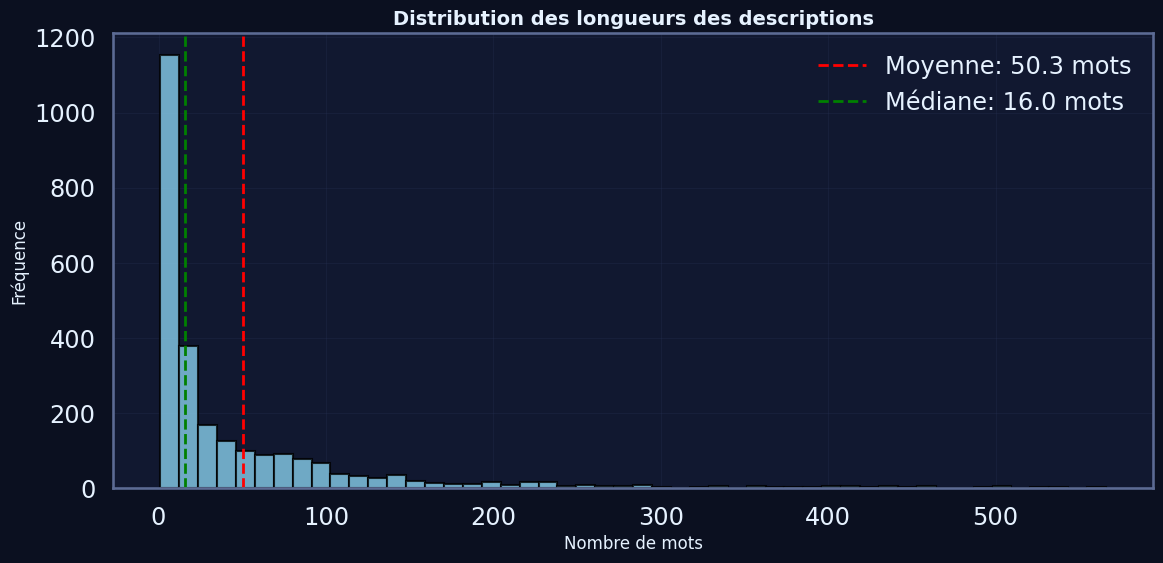


Statistiques détaillées :

Métrique                       Valeur              
-------------------------------------------------------
Nombre total de descriptions   2598                
Longueur moyenne (mots)        50.3                
Longueur médiane (mots)        16.0                
Min / Max (mots)               1 / 566                 


In [47]:
print("Analyse des longueurs et distribution du corpus TrAIn.me\n")

# Longueurs des descriptions
desc_lengths = df["description"].astype(str).apply(lambda x: len(x.split()))

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.hist(desc_lengths, bins=50, color='skyblue', edgecolor='black', alpha=0.8)
ax.axvline(np.mean(desc_lengths), color='red', linestyle='--', linewidth=2,
           label=f"Moyenne: {np.mean(desc_lengths):.1f} mots")
ax.axvline(np.median(desc_lengths), color='green', linestyle='--', linewidth=2,
           label=f"Médiane: {np.median(desc_lengths):.1f} mots")

ax.set_xlabel("Nombre de mots", fontsize=12)
ax.set_ylabel("Fréquence", fontsize=12)
ax.set_title("Distribution des longueurs des descriptions", fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

# Statistiques
print("\nStatistiques détaillées :\n")
print(f"{'Métrique':<30} {'Valeur':<20}")
print("-" * 55)
print(f"{'Nombre total de descriptions':<30} {len(desc_lengths):<20}")
print(f"{'Longueur moyenne (mots)':<30} {np.mean(desc_lengths):<20.1f}")
print(f"{'Longueur médiane (mots)':<30} {np.median(desc_lengths):<20.1f}")
print(f"{'Min / Max (mots)':<30} {desc_lengths.min()} / {desc_lengths.max():<20}")

### Data cleaning des données non-structuées
#### Filtrage des descriptions : détection des textes peu informatifs

In [48]:
GENERIC_PATTERNS = [
    r"^n/?a$",
    r"^no description$",
    r"^none$",
    r"^-$",
    r"^program description$",
    r"^program$",
]

def is_low_info(text: str) -> bool:
    """
    Détecte les descriptions peu informatives :
    - très courtes
    - bourrées de caractères non alphabétiques
    - répétitives ou génériques
    """
    if not isinstance(text, str):
        return True

    txt = text.strip().lower()

    # Vide après strip
    if txt == "":
        return True

    # Expressions génériques connues
    for pat in GENERIC_PATTERNS:
        if re.fullmatch(pat, txt):
            return True

    # Compter mots / caractères
    words = txt.split()
    n_words = len(words)
    n_chars = len(txt)

    # Très court : on marque comme faible info
    if n_words < 5 or n_chars < 20:
        return True

    # Proportion de lettres vs tout le reste
    letters = sum(ch.isalpha() for ch in txt)
    ratio_letters = letters / max(1, n_chars)
    if ratio_letters < 0.5:
        # Trop de chiffres/symboles → souvent du bruit
        return True

    # Répétition : peu de mots uniques par rapport au total
    unique_words = len(set(words))
    if n_words >= 10 and unique_words / n_words < 0.3:
        return True

    return False


def clean_program_descriptions(df: pd.DataFrame,
                               desc_col: str = "description") -> pd.DataFrame:
    """
    Applique un filtre qualité sur les descriptions de programmes.

    - Supprime les lignes avec description vide / NaN
    - Ajoute des métriques de longueur
    - Marque les descriptions peu informatives
    - Retourne un df filtré + les colonnes de diagnostic
    """
    df = df.copy()

    # Forcer string, gérer NaN
    df[desc_col] = df[desc_col].astype(str).str.strip()
    df["desc_is_nan"] = df[desc_col].isna() | (df[desc_col] == "")

    # Longueurs brutes
    df["desc_n_chars"] = df[desc_col].str.len()
    df["desc_n_words"] = df[desc_col].apply(lambda x: len(x.split()))

    # Flag qualité (low info)
    df["desc_low_info"] = df[desc_col].apply(is_low_info)

    # Décision finale : à garder si non-NaN et pas low_info
    df["keep_for_corpus"] = (~df["desc_is_nan"]) & (~df["desc_low_info"])

    print("\nFiltre qualité descriptions")
    print(f"Total lignes       : {len(df)}")
    print(f"Descriptions gardées : {df['keep_for_corpus'].sum()}")
    print(f"Descriptions rejetées : {(~df['keep_for_corpus']).sum()}")
    print("----------------------------------------")
    print("Raisons principales (approx) :")
    print(f"- NaN / vide / ultra-court : "
          f"{(df['desc_n_words'] < 5).sum()} lignes")
    print(f"- Low info (pattern / bruit / répétition) : "
          f"{df['desc_low_info'].sum()} lignes")

    # Retourner uniquement les lignes retenues, mais AVEC les métriques utiles
    return df[df["keep_for_corpus"]].reset_index(drop=True)

df = clean_program_descriptions(df, desc_col="description")
print(df.head())


Filtre qualité descriptions
Total lignes       : 2598
Descriptions gardées : 1994
Descriptions rejetées : 604
----------------------------------------
Raisons principales (approx) :
- NaN / vide / ultra-court : 599 lignes
- Low info (pattern / bruit / répétition) : 604 lignes
                                               title                                        description  \
0  (MASS MONSTER) High Intensity 4 Day Upper Lowe...  Build tones of muscular with this high intensi...   
1  1 PowerLift Per Day Powerbuilding 5 Day Bro Split  Based off of Andy Baker's KCS (Kingwood Streng...   
2                      10 Week Mass Building Program  This workout is designed to increase your musc...   
3                            100 Push Ups in 6 Weeks  3 day a week push up program gradually increas...   
4                               100x Push Up’s / Day                100x push up’s per day for 12 weeks   

                                    level                                      

### Nettoyage “mécanique” (puces, ponctuation, espaces)

In [49]:
BULLET_CHARS = "•●▪◦*-"

def normalize_style_basic(text: str) -> str:
    if not isinstance(text, str):
        return ""

    txt = text.replace("\r\n", "\n").replace("\r", "\n")

    # Échapper les caractères spéciaux pour la classe de caractères
    bullet_escaped = re.escape(BULLET_CHARS)

    # Enlever les puces en début de ligne
    #    Ex : "• Day 1: ..." → "Day 1: ..."
    txt = re.sub(rf"^[{bullet_escaped}\s]+\s*", "", txt, flags=re.MULTILINE)

    # Remplacer les puces isolées par des espaces
    txt = re.sub(rf"[{bullet_escaped}]", " ", txt)

    # Normaliser la ponctuation
    txt = re.sub(r"\s*([.,!?;:])\s*", r"\1 ", txt)

    # Coller les unités / %
    txt = re.sub(r"\s+(%|kg|lbs|reps?|sets?)", r" \1", txt)

    # Réduire les espaces multiples
    txt = re.sub(r"\s+", " ", txt)

    # Nettoyer les espaces avant ponctuation finale
    txt = re.sub(r"\s+([.,!?])", r"\1", txt)

    return txt.strip()

# Gérer les répétitions et phrases cassées
def clean_sentences(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Split en pseudo-phrases
    sentences = re.split(r'(?<=[.!?])\s+', text.strip())

    cleaned = []
    seen = set()

    for s in sentences:
        s = s.strip()
        if not s:
            continue

        # Virer les phrases ultra-courtes (cassées ou sans info)
        #    ex : "and continue", "get the results"
        word_count = len(s.split())
        if word_count < 4:
            continue

        # Éviter les répétitions exactes
        key = s.lower()
        if key in seen:
            continue
        seen.add(key)

        cleaned.append(s)

    # Recolle proprement
    text_cleaned = " ".join(cleaned).strip()

    # Si ça ne finit pas par une ponctuation, ajouter un point
    if text_cleaned and text_cleaned[-1] not in ".!?":
        text_cleaned += "."

    return text_cleaned

In [50]:
# Filtrer les descriptions trop courtes (<10–12 mots)
df = df[df["description"].str.split().str.len() >= 10]
# Filtrer les descriptions trop longues (>250–300 mots)
df = df[df["description"].str.split().str.len() <= 300]
# Supprimer les listes structurées / blocs programmés trop complexes
df[df["description"].str.contains(r"(Day|Week|•|Part|Cycle)", case=False)]
# Supprimer les descriptions tronquées
df[df["description"].str.endswith(("and", "with", "to", "for", ","))]
# Supprimer les descriptions marketing trop verbeuses
df[df["description"].str.contains(r"(life-altering|transform|physique|turns heads)", case=False)]
df["description_norm"] = (
    df["description"]
      .astype(str)
      .apply(normalize_style_basic)
      .apply(clean_sentences)
)
# Exclure les descriptions qui contiennent beaucoup de dates
pattern_date = r"\d{4}-\d{2}-\d{2} \d{2}:\d{2}"

mask_too_many_dates = (
    df["description"]
      .astype(str)
      .str.findall(pattern_date)
      .apply(len) > 2
)

# Exclure celles qui contiennent des listes Python brutes
mask_lists = df["description"].astype(str).str.contains(r"\['.*?'\]", regex=True)

df = df[~(mask_too_many_dates | mask_lists)].copy()

### Préparation des données pour le fine-tuning de GPT-2 et sépration train / val

In [ ]:
print(f"Configuration du fine-tuning :")
print(f"  - Longueur max des séquences : {MAX_LENGTH} tokens")
print(f"  - Échantillons d'entraînement : {NUM_TRAIN_SAMPLES}")
print(f"  - Échantillons de validation : {NUM_VAL_SAMPLES}")
print(f"  - Batch size : {BATCH_SIZE}")


def prepare_trainme_corpus(df_split, num_samples, add_prompt=True):
    """
    Prépare les données program_summary.csv pour le fine-tuning GPT-2.

    Args:
        df_split (DataFrame): fraction du dataset (train ou validation)
        num_samples (int): nombre total de lignes à utiliser
        add_prompt (bool): ajoute un prefix structuré si True

    Retour:
        List[str]: liste de textes formatés pour l'entraînement
    """
    textes = []

    # Limiter à num_samples lignes
    df_subset = df_split.head(num_samples)

    for _, row in df_subset.iterrows():
        title = str(row.get("title", "")).strip()
        desc = str(row.get("description", "")).strip()

        if add_prompt:
            # Format structuré et simple pour le modèle
            texte = f"Exercise: {title}\nDescription: {desc}"
        else:
            texte = desc

        textes.append(texte)

    return textes


print("\nPréparation des données...\n")

# Shuffle pour éviter les ordres biaisés
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split train / validation (simple ratio)
train_df = df_shuffled.iloc[:NUM_TRAIN_SAMPLES]
val_df   = df_shuffled.iloc[NUM_TRAIN_SAMPLES : NUM_TRAIN_SAMPLES + NUM_VAL_SAMPLES]

# Préparation des textes
train_texts = prepare_trainme_corpus(train_df, NUM_TRAIN_SAMPLES)
val_texts   = prepare_trainme_corpus(val_df, NUM_VAL_SAMPLES)

print("Données préparées !")
print(f"  - Train : {len(train_texts)} descriptions")
print(f"  - Val   : {len(val_texts)} descriptions")

# Exemple de texte formaté
print("\nExemple de texte formaté :\n")
example_preview = train_texts[0][:300] + "..."
print(textwrap.fill(example_preview, width=80))

Configuration du fine-tuning :
  - Longueur max des séquences : 128 tokens
  - Échantillons d'entraînement : 1356
  - Échantillons de validation : 240
  - Batch size : 8

Préparation des données...

Données préparées !
  - Train : 1356 descriptions
  - Val   : 150 descriptions

Exemple de texte formaté :

Exercise: Get your GF in the Gym (Girl Fitness Program) Description: Full-body
workout mostly for women. Beginner-friendly. Originally designed by Natural
Hypertrophy. Props to him....


### Construction du Dataset PyTorch pour le Fine-Tuning

In [52]:
# Utilisation du MAX_LENGTH déjà défini plus haut
class GPT2TextDataset(Dataset):
    """
    Dataset PyTorch pour le fine-tuning GPT-2 sur les descriptions d'exercices.
    Chaque entrée contient :
      - input_ids
      - attention_mask
      - labels (identiques à input_ids pour causal LM)
    """
    def __init__(self, texts, tokenizer, max_length=MAX_LENGTH):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]

        # Encodage tokenizer HuggingFace
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        # Retirer la dimension batch (1, seq_len → seq_len)
        enc = {k: v.squeeze(0) for k, v in enc.items()}

        # Pour un modèle causal LM : labels = input_ids
        enc["labels"] = enc["input_ids"].clone()

        return enc


# Construction des datasets entraînement / validation
train_dataset = GPT2TextDataset(train_texts, tokenizer)
val_dataset   = GPT2TextDataset(val_texts, tokenizer)

# BATCH_SIZE déjà défini plus haut ou configurable
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

print("Datasets PyTorch prêts pour le fine-tuning !")
print(f"  - Train : {len(train_dataset)} exemples")
print(f"  - Val   : {len(val_dataset)} exemples")

Datasets PyTorch prêts pour le fine-tuning !
  - Train : 1356 exemples
  - Val   : 150 exemples


## Baseline : Feature Extraction (Modèle Frozen)

**Feature Extraction**--> **geler toutes les couches** du modèle et train que la tête de sortie.

In [ ]:
# Charger un modèle GPT-2 indépendant pour l'approche frozen
frozen_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)
frozen_model = frozen_model.to(device)

# FREEZE le backbone GPT-2 (tous les blocs Transformer)
#    --> le modèle conserve ses représentations internes
for param in frozen_model.transformer.parameters():
    param.requires_grad = False

# 2Laisser la tête de sortie entraînable (lm_head)
#    --> seule la "sortie" est ajustée au style du corpus TrAIn.me
for param in frozen_model.lm_head.parameters():
    param.requires_grad = True

# Comptage des paramètres
total_params = sum(p.numel() for p in frozen_model.parameters())
trainable_params = sum(p.numel() for p in frozen_model.parameters() if p.requires_grad)
frozen_params = total_params - trainable_params

print("Modèle frozen créé !\n")
print("Paramètres :")
print(f"  - Total         : {total_params:,}")
print(f"  - Trainable     : {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")
print(f"  - Frozen        : {frozen_params:,} ({100 * frozen_params / total_params:.2f}%)")

print("\nLe backbone Transformer est entièrement gelé :")
print("   --> GPT-2 agit comme extracteur de features,")
print("   --> seule la tête de sortie (lm_head) apprendra le style du corpus sportif.")


Modèle frozen créé !

Paramètres :
  - Total         : 124,439,808
  - Trainable     : 38,597,376 (31.02%)
  - Frozen        : 85,842,432 (68.98%)

Le backbone Transformer est entièrement gelé :
   → GPT-2 agit comme extracteur de features,
   → seule la tête de sortie (lm_head) apprendra le style du corpus sportif.


### Entraînement du modèle Frozen (Feature Extraction)

In [ ]:
config = GPT2Config.from_pretrained(INPUT_MODEL_NAME)
config.loss_type = "ForCausalLMLoss"

# Charger le modèle avec cette config
frozen_model = GPT2LMHeadModel.from_pretrained(
    INPUT_MODEL_NAME,
    config=config
)

frozen_model.to(device)
frozen_model.train()

optimizer = AdamW(
    (p for p in frozen_model.parameters() if p.requires_grad),
    lr=LR_FROZEN
)

history_frozen = {"loss": [], "val_loss": []}

print("Entraînement du modèle GPT-2 FROZEN (feature extraction) — boucle PyTorch\n")

for epoch in range(EPOCHS_FROZEN):

    # Phase TRAIN
    frozen_model.train()
    train_loss_sum = 0.0

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = frozen_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],  # GPT-2 renvoie directement la loss
        )

        loss = outputs.loss
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

        # Logging toutes les 20 itérations
        if (step + 1) % 20 == 0:
            print(f"  [Epoch {epoch+1}/{EPOCHS_FROZEN}] step {step+1}/{len(train_loader)} — loss: {loss.item():.4f}")

    avg_train_loss = train_loss_sum / len(train_loader)

    # Phase VALIDATION
    frozen_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = frozen_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    # Stockage des métriques
    history_frozen["loss"].append(avg_train_loss)
    history_frozen["val_loss"].append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS_FROZEN} — loss: {avg_train_loss:.4f} — val_loss: {avg_val_loss:.4f}")

print("\nEntraînement FROZEN terminé ! (baseline 'Feature Extraction')\n")

Entraînement du modèle GPT-2 FROZEN (feature extraction) — boucle PyTorch

  [Epoch 1/8] step 20/170 — loss: 2.8123
  [Epoch 1/8] step 40/170 — loss: 1.6582
  [Epoch 1/8] step 60/170 — loss: 1.7066
  [Epoch 1/8] step 80/170 — loss: 2.0747
  [Epoch 1/8] step 100/170 — loss: 1.5240
  [Epoch 1/8] step 120/170 — loss: 1.6758
  [Epoch 1/8] step 140/170 — loss: 1.6051
  [Epoch 1/8] step 160/170 — loss: 2.4487
Epoch 1/8 — loss: 2.2382 — val_loss: 1.9638
  [Epoch 2/8] step 20/170 — loss: 1.8100
  [Epoch 2/8] step 40/170 — loss: 2.0329
  [Epoch 2/8] step 60/170 — loss: 1.6640
  [Epoch 2/8] step 80/170 — loss: 1.3854
  [Epoch 2/8] step 100/170 — loss: 1.5984
  [Epoch 2/8] step 120/170 — loss: 2.0336
  [Epoch 2/8] step 140/170 — loss: 0.7157
  [Epoch 2/8] step 160/170 — loss: 1.6987
Epoch 2/8 — loss: 1.6697 — val_loss: 1.9574
  [Epoch 3/8] step 20/170 — loss: 0.9494
  [Epoch 3/8] step 40/170 — loss: 1.0580
  [Epoch 3/8] step 60/170 — loss: 1.2416
  [Epoch 3/8] step 80/170 — loss: 1.0986
  [Epoch 

### Test du modèle Frozen

In [ ]:
# Prompts de test adaptés au domaine sportif TrAIn.me
test_prompts_frozen = [
    "Start your warm-up with",
    "For a full-body workout, perform",
    "To improve your cardio, try to"
]

# S’assurer que le modèle est bien sur le bon device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
frozen_model.to(device)
frozen_model.eval()

# GPT-2 n’a pas de token PAD → on utilise eos_token_id
eos_token_id = tokenizer.eos_token_id

for prompt in test_prompts_frozen:
    print(f"\nPrompt: '{prompt}'")

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        output_ids = frozen_model.generate(
            **inputs,
            max_new_tokens=40, # nombre maximum de tokens générés
            pad_token_id=eos_token_id,
            eos_token_id=eos_token_id,
            do_sample=True, # sampling aléatoire
            top_p=0.9, # nucleus sampling
            temperature=0.8, # créativité modérée
        )

    # Décode la séquence complète (prompt + génération)
    full_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    print("> Généré :")
    print(textwrap.fill(full_text, width=75))


## Fine-Tuning Complet (Unfrozen)

**Vrai fine-tuning** de GPT-2 = déverrouillant toutes les couches du modèle

In [ ]:
# Chargement d'un modèle GPT-2 "neuf" (séparé du modèle frozen)
finetuned_model = AutoModelForCausalLM.from_pretrained(INPUT_MODEL_NAME)

# Placement sur le device adéquat
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
finetuned_model.to(device)

# Chez HuggingFace, tous les paramètres sont trainables par défaut
trainable_params = sum(p.numel() for p in finetuned_model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in finetuned_model.parameters())

print("Modèle FULL fine-tuning créé !\n")
print("Paramètres :")
print(f"  - Total      : {total_params:,}")
print(f"  - Trainable  : {trainable_params:,} ({100 * trainable_params / total_params:.2f}%)")

print("\nToutes les couches GPT-2 sont dégelées — le fine-tuning complet est prêt !")

### Entraînement complet du modèle GPT-2 (Fine-Tuning)

In [ ]:
# # On réutilise train_dataset et val_dataset créés précédemment
# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

# # Préparation du modèle
# finetuned_model.to(device)
# finetuned_model.train()

# optimizer = AdamW(
#     (p for p in finetuned_model.parameters() if p.requires_grad),
#     lr=LR_FULL
# )

# history_finetune = {"loss": [], "val_loss": []}

# print("Fine-tuning complet du modèle GPT-2 (PyTorch loop)…\n")

# for epoch in range(EPOCHS_FULL):

#     # Phase TRAIN
#     finetuned_model.train()
#     train_loss_sum = 0.0

#     for step, batch in enumerate(train_loader):
#         batch = {k: v.to(device) for k, v in batch.items()}

#         outputs = finetuned_model(
#             input_ids=batch["input_ids"],
#             attention_mask=batch["attention_mask"],
#             labels=batch["labels"], # labels = input_ids, définis dans le Dataset
#         )

#         loss = outputs.loss
#         loss.backward()

#         optimizer.step()
#         optimizer.zero_grad()

#         train_loss_sum += loss.item()

#         # Logging toutes les 20 étapes
#         if (step + 1) % 20 == 0:
#             print(f"[Epoch {epoch+1}/{EPOCHS_FULL}] step {step+1}/{len(train_loader)} — loss: {loss.item():.4f}")

#     avg_train_loss = train_loss_sum / len(train_loader)

#     # Phase VALIDATION
#     finetuned_model.eval()
#     val_loss_sum = 0.0

#     with torch.no_grad():
#         for batch in val_loader:
#             batch = {k: v.to(device) for k, v in batch.items()}

#             outputs = finetuned_model(
#                 input_ids=batch["input_ids"],
#                 attention_mask=batch["attention_mask"],
#                 labels=batch["labels"],
#             )

#             val_loss_sum += outputs.loss.item()

#     avg_val_loss = val_loss_sum / len(val_loader)

#     history_finetune["loss"].append(avg_train_loss)
#     history_finetune["val_loss"].append(avg_val_loss)

#     print(f"Epoch {epoch+1}/{EPOCHS_FULL} — loss: {avg_train_loss:.4f} — val_loss: {avg_val_loss:.4f}")

# print("\nFine-tuning complet terminé (GPT-2 Unfrozen) !\n")

### Visualisation dynamique du fine-tuning

In [ ]:
# Callback
class FineTuneVisualizer:
    def __init__(self, total_epochs):
        self.total_epochs = total_epochs
        self.train_losses = []
        self.val_losses = []

    def update(self, epoch, train_loss, val_loss):
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)

        clear_output(wait=True)

        # Graphiques
        plt.figure(figsize=(14, 5))

        # Courbe des pertes (train / val)
        plt.subplot(1, 2, 1)
        plt.plot(self.train_losses, "o-", color="blue", label="Train Loss")
        plt.plot(self.val_losses, "o-", color="orange", label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Progression du Fine-Tuning GPT-2 (TrAIn.me)", fontsize=14)
        plt.grid(alpha=0.3)
        plt.legend()

        # Aperçu de l'amélioration
        plt.subplot(1, 2, 2)
        if len(self.train_losses) > 1:
            improvement = ((self.train_losses[0] - self.train_losses[-1]) /
                           self.train_losses[0]) * 100
            plt.bar(
                ["Initial", "Actuel"],
                [self.train_losses[0], self.train_losses[-1]],
                color=["lightcoral", "lightgreen"],
                edgecolor="black",
            )
            plt.title(f"Amélioration : {improvement:.1f}%", fontsize=14)
            plt.ylabel("Loss")
            plt.grid(alpha=0.3, axis="y")

        plt.tight_layout()
        plt.show()

        print(f"Epoch {epoch+1}/{self.total_epochs}")
        print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")

### Entraînement fine-tuning du modèle GPT-2

In [ ]:
# On réutilise train_dataset et val_dataset créés précédemment
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

# Activation du visualizer
visualizer = FineTuneVisualizer(total_epochs=EPOCHS_FULL)

print("Visualisation activée — début de l'entraînement...\n")

history_finetune = {"loss": [], "val_loss": []}

# Boucle de fine-tuning complet
for epoch in range(EPOCHS_FULL):

    # Phase TRAIN
    finetuned_model.train()
    train_loss_sum = 0.0

    for batch in train_loader:
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = finetuned_model(
            input_ids=batch["input_ids"],
            attention_mask=batch["attention_mask"],
            labels=batch["labels"],    # causal LM
        )
        loss = outputs.loss

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        train_loss_sum += loss.item()

    avg_train_loss = train_loss_sum / len(train_loader)

    # Phase VALIDATION
    finetuned_model.eval()
    val_loss_sum = 0.0

    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = finetuned_model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"],
            )
            val_loss_sum += outputs.loss.item()

    avg_val_loss = val_loss_sum / len(val_loader)

    history_finetune["loss"].append(avg_train_loss)
    history_finetune["val_loss"].append(avg_val_loss)

    # Mise à jour du visualizer
    visualizer.update(epoch, avg_train_loss, avg_val_loss)

print("\nFine-tuning complet terminé !")

## Comparaison des Trois Modèles

GPT-2 pré-entraîné (sans aucune adaptation) VS Modèle Frozen et Feature Extraction (backbone gelé, dernières couches ajustées VS Modèle Fine-Tuned (Unfrozen, toutes les couches sont dégelées)

In [ ]:
# Comparaison des courbes d’apprentissage (PyTorch)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Training Loss
axes[0].plot(
    history_frozen["loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[0].plot(
    history_finetune["loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-Tuned (Unfrozen)",
)
axes[0].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Training Loss", fontsize=12, fontweight="bold")
axes[0].set_title("Comparaison des Training Loss", fontsize=14, fontweight="bold")
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Validation Loss
axes[1].plot(
    history_frozen["val_loss"],
    "o-",
    color="blue",
    linewidth=2,
    markersize=8,
    label="Frozen (Feature Extraction)",
)
axes[1].plot(
    history_finetune["val_loss"],
    "o-",
    color="red",
    linewidth=2,
    markersize=8,
    label="Fine-Tuned (Unfrozen)",
)
axes[1].set_xlabel("Epoch", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Validation Loss", fontsize=12, fontweight="bold")
axes[1].set_title("Comparaison des Validation Loss", fontsize=14, fontweight="bold")
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle(
    "GPT-2 — Feature Extraction vs Fine-Tuning (Corpus TrAIn.me)",
    fontsize=16,
    fontweight="bold",
    y=1.02
)
plt.show()

# Tableau comparatif
print("\nRésumé des performances (Train.me GPT-2)\n")
print(f"{'Modèle':<30} {'Train Loss Finale':<20} {'Val Loss Finale':<20}")

frozen_train_last = history_frozen["loss"][-1]
frozen_val_last = history_frozen["val_loss"][-1]
ft_train_last = history_finetune["loss"][-1]
ft_val_last = history_finetune["val_loss"][-1]

print(f"{'Frozen (Feature Extraction)':<30} {frozen_train_last:<20.4f} {frozen_val_last:<20.4f}")
print(f"{'Fine-Tuned (Unfrozen)':<30} {ft_train_last:<20.4f} {ft_val_last:<20.4f}")

# Amélioration (%) sur la validation loss
improvement = ((frozen_val_last - ft_val_last) / frozen_val_last) * 100

if improvement > 0:
    print(f"\nAmélioration : le fine-tuning réduit la validation loss de {improvement:.1f}%")
else:
    print(f"\nLe modèle frozen performe mieux")

### Comparaison qualitative : génération de texte

In [ ]:
print("\nComparaison des trois modèles sur les mêmes prompts :\n")

# Prompts de test adaptés au domaine sportif TrAIn.me
test_prompts_comparison = [
    "Start your warm-up with",
    "For a full-body workout, perform",
    "To improve your cardio, try to"
]

# STOP TOKENS pour GPT-2
STOP_TOKENS = [tokenizer.eos_token_id]

models_to_compare = [
    ("GPT-2 Pré-entraîné (baseline)", gpt2_model, "1"),
    ("Feature Extraction (Frozen)", frozen_model, "2"),
    ("Fine-Tuned (Unfrozen)", finetuned_model, "3"),
]

for prompt in test_prompts_comparison:
    print(f"Prompt: '{prompt}'")
    for model_name, model, emoji in models_to_compare:

        model.eval()
        model.to(device)

        # Tokenisation
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        # Génération classique PyTorch
        output_ids = model.generate(
            **inputs,
            max_length=100,
            eos_token_id=STOP_TOKENS[0],
            pad_token_id=tokenizer.eos_token_id,
        )

        generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

        print(f"{emoji} {model_name}:")
        print(textwrap.fill(
            generated_text,
            width=75,
            initial_indent="   ",
            subsequent_indent="   "
        ))
        print()

### 7.3. Sélection et sauvegarde AUTOMATIQUE du meilleur modèle

In [ ]:
print("Sélection du meilleur modèle sur la base de la validation loss finale...\n")

# Récupération des dernières val_loss
frozen_val_last = history_frozen["val_loss"][-1]
ft_val_last     = history_finetune["val_loss"][-1]

print(f"Frozen (Feature Extraction)  - Val Loss finale : {frozen_val_last:.4f}")
print(f"Fine-Tuned (Unfrozen)       - Val Loss finale : {ft_val_last:.4f}")

# Choix du meilleur modèle
if ft_val_last < frozen_val_last:
    best_name = "Fine-Tuned (Unfrozen)"
    best_key  = "finetuned"
    best_model = finetuned_model
    best_val_loss = ft_val_last
else:
    best_name = "Frozen (Feature Extraction)"
    best_key  = "frozen"
    best_model = frozen_model
    best_val_loss = frozen_val_last

print(f"Meilleur modèle : {best_name}")
print(f"   --> Val Loss : {best_val_loss:.4f}\n")

# Sauvegarde du meilleur modèle (HF format)
best_model_dir = project_root / "models" / OUTPUT_MODEL_NAME
best_model_dir.mkdir(parents=True, exist_ok=True)

best_model.save_pretrained(best_model_dir)
tokenizer.save_pretrained(best_model_dir)

print(f"Modèle sauvegardé dans : {best_model_dir}\n")

print("Contenu du dossier :")
for f in best_model_dir.iterdir():
    print("   -", f.name)

print("\nLe meilleur modèle GPT-2 (selon la val_loss) est maintenant enregistré pour TrAIn.me.")

## Génération interactive du meilleur modèle

In [ ]:
def generer_exercice_interactif(
    model,
    workout_type: str = "strength",
    debut: str = "",
    num_samples: int = 3,
    max_length: int = 120,
    temperature: float = 1.0,
):
    """
    Génère plusieurs descriptions d'exercices / consignes d'entraînement
    avec GPT-2 fine-tuned sur le corpus TrAIn.me.

    Args:
        model : Modèle HuggingFace (AutoModelForCausalLM, ex : GPT-2)
        workout_type : catégorie de l’exercice (ex : strength, cardio, mobility…)
        debut : début de phrase fourni par l'utilisateur
        num_samples : nombre d'exemples générés
        max_length : longueur maximale en tokens
        temperature : contrôle la créativité (>1 plus créatif)
    """

    # Construction du prompt
    if debut:
        prompt = f"Workout [{workout_type}]: {debut}"
    else:
        prompt = f"Workout [{workout_type}]:"

    print(f"\nGénération de {num_samples} exemples ({workout_type.upper()})")
    print(f"Prompt de départ : '{prompt}'\n")

    model.to(device)
    model.eval()

    for i in range(num_samples):

        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        with torch.no_grad():
            output_ids = model.generate(
                **inputs,
                max_length=max_length,
                do_sample=True,
                temperature=temperature,
                top_k=50,
                top_p=0.95,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.eos_token_id,
            )

        # Décodage
        generated_text = tokenizer.decode(
            output_ids[0],
            skip_special_tokens=True
        )

        print(f"\n> Exemple #{i+1} :")
        print(
            textwrap.fill(
                generated_text,
                width=75,
                initial_indent="   ",
                subsequent_indent="   ",
            )
        )
        print("-" * 80)



# Exemples d'utilisation
print("\nGÉNÉRATION INTERACTIVE AVEC GPT-2 (Fine-Tuned TrAIn.me)\n")

# Exemple : Force
generer_exercice_interactif(
    finetuned_model,
    workout_type="strength",
    debut="Start your session with",
    num_samples=2,
)

# Exemple : Cardio
generer_exercice_interactif(
    finetuned_model,
    workout_type="cardio",
    debut="To increase your endurance, try to",
    num_samples=2,
)

### Tests personnalisés

In [ ]:
MON_TYPE = "strength" # Exemple : strength, cardio, mobility, fat_loss
MON_DEBUT = "Start your warm-up with" # Début de phrase personnalisé
NOMBRE_EXEMPLES = 3
MAX_LEN = 120 # Longueur max de génération
TEMP = 1.0 # Température (1.0 = neutre, >1 = plus créatif)

print(f"Type d'entraînement choisi : {MON_TYPE.upper()}")

# Construction du prompt
if MON_DEBUT:
    prompt_perso = f"Workout [{MON_TYPE}]: {MON_DEBUT}"
else:
    prompt_perso = f"Workout [{MON_TYPE}]:"

# Device + mode eval
finetuned_model.to(device)
finetuned_model.eval()

for i in range(NOMBRE_EXEMPLES):

    # Tokenisation
    inputs = tokenizer(prompt_perso, return_tensors="pt").to(device)

    # Génération
    with torch.no_grad():
        output_ids = finetuned_model.generate(
            **inputs,
            max_length=MAX_LEN,
            do_sample=True,
            temperature=TEMP,
            top_k=50,
            top_p=0.95,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id,
        )

    # Décodage
    generated_text = tokenizer.decode(
        output_ids[0],
        skip_special_tokens=True
    )

    print(f"\nExemple #{i+1}:")
    print(textwrap.fill(
        generated_text,
        width=75,
        initial_indent="   ",
        subsequent_indent="   "
    ))

## Informations relatives au modèle (son nom et les métriques associées)

In [ ]:
print("\nFINE-TUNING GPT-2 — MODEL REPORT\n")
# Répertoire où le modèle fine-tuned a été sauvegardé
model_dir = best_model_dir   # défini lors du checkpoint ModelCheckpoint
report_path = model_dir / "GPT2_Fine_Tuning_model_report.json"

# Récupération des métriques (callbacks)
final_val_loss = float(history_finetune["val_loss"][-1])
final_train_loss = float(history_finetune["loss"][-1])

best_loss = min(final_val_loss, final_train_loss)

# Compter les paramètres du modèle
total_params = sum(p.numel() for p in model.parameters())
size_mb = total_params * 4 / (1024**2)

# Construction du rapport
report = {
    "created_at": datetime.utcnow().isoformat() + "Z",
    "task": "language_modeling",
    "target": "next_token_prediction",
    "n_train_samples": int(NUM_TRAIN_SAMPLES),
    "n_val_samples": int(NUM_VAL_SAMPLES),
    "sequence_length": int(MAX_LENGTH),
    "device": str(device),

    "model": {
        "name": OUTPUT_MODEL_NAME,
        "type": "GPT2_Fine_Tuned",
        "model_path": str(model_dir.resolve()),
        "total_params": int(total_params),
        "size_mb": round(size_mb, 2),
    },

    "training": {
        "epochs_frozen": int(EPOCHS_FROZEN),
        "epochs_full_finetuning": int(EPOCHS_FULL),
        "lr_frozen": float(LR_FROZEN),
        "lr_full": float(LR_FULL),
        "batch_size": int(BATCH_SIZE),
        "optimizer": "AdamW"
    },

    "metrics": {
        "train_loss_last_epoch": final_train_loss,
        "val_loss_last_epoch": final_val_loss,
        "best_loss": best_loss
    }
}

# Impression console
for section, value in report.items():
    if isinstance(value, dict):
        print(f"- {section}:")
        for k, v in value.items():
            print(f"    • {k}: {v}")
    else:
        print(f"- {section}: {value}")

# Sauvegarde JSON
with open(report_path, "w", encoding="utf-8") as f:
    json.dump(report, f, ensure_ascii=False, indent=2)

print(f"\nRapport JSON enregistré : {report_path}")